## Diwali sales analysis

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
from scipy.stats import skew, kurtosis
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

## Task 1: Data Understanding

In [3]:
# Load dataset
df = pd.read_csv('Diwali Sales Data.csv', encoding='unicode_escape')

# Simulation of Profit and Discount (as they are missing but required)
np.random.seed(42)
df['Discount'] = np.random.uniform(0, 0.2, size=len(df))
df['Sales'] = df['Amount'] # Using Amount as Sales
df['Profit'] = df['Sales'] * np.random.uniform(0.05, 0.25, size=len(df))
df['Quantity'] = df['Orders'] # Using Orders as Quantity

print("First 5 rows:")
display(df.head())
print("\nDataset shape:", df.shape)
print("\nColumn names:", df.columns.tolist())

print("\nData Categorization:")
print("Quantitative (Discrete): Orders/Quantity, Age")
print("Quantitative (Continuous): Sales/Amount, Profit, Discount")
print("Qualitative (Nominal): Gender, State, Zone, Occupation")

First 5 rows:


,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1,Discount,Sales,Profit,Quantity
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN,0.074908,23952.0,4636.474154,1
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN,0.190143,23934.0,5490.643970,3
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN,0.146399,23924.0,5510.853572,3
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN,0.119732,23912.0,2766.661701,2
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN,0.031204,23877.0,5742.185762,2



Dataset shape: (11251, 19)

Column names: ['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age', 'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category', 'Orders', 'Amount', 'Status', 'unnamed1', 'Discount', 'Sales', 'Profit', 'Quantity']

Data Categorization:
Quantitative (Discrete): Orders/Quantity, Age
Quantitative (Continuous): Sales/Amount, Profit, Discount
Qualitative (Nominal): Gender, State, Zone, Occupation


## Task 3: Handling Missing Data and Outliers

In [4]:
print("Missing values before cleaning:")
print(df.isnull().sum())

# Cleaning
df.drop(['Status', 'unnamed1'], axis=1, inplace=True, errors='ignore')
df.dropna(subset=['Amount'], inplace=True)
df['Sales'] = df['Amount'].astype(int)

# Outlier handling function
def handle_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    data[column] = np.clip(data[column], lower_bound, upper_bound)
    return data

df = handle_outliers(df, 'Sales')
print("\nOutliers handled by clipping based on IQR.")

Missing values before cleaning:
User_ID                 0
Cust_name               0
Product_ID              0
Gender                  0
Age Group               0
Age                     0
Marital_Status          0
State                   0
Zone                    0
Occupation              0
Product_Category        0
Orders                  0
Amount                 12
Status              11251
unnamed1            11251
Discount                0
Sales                  12
Profit                 12
Quantity                0
dtype: int64

Outliers handled by clipping based on IQR.


## Task 5: Automating EDA

In [5]:
def automated_eda(data):
    print("--- Automated EDA Report ---")
    print("\nInfo:")
    data.info()
    print("\nDescription:")
    display(data.describe())
    print("\nCorrelation Matrix:")
    numeric_df = data.select_dtypes(include=[np.number])
    display(numeric_df.corr())

automated_eda(df)

--- Automated EDA Report ---

Info:
<class 'pandas.core.frame.DataFrame'>
Index: 11239 entries, 0 to 11250
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11239 non-null  int64  
 1   Cust_name         11239 non-null  object 
 2   Product_ID        11239 non-null  object 
 3   Gender            11239 non-null  object 
 4   Age Group         11239 non-null  object 
 5   Age               11239 non-null  int64  
 6   Marital_Status    11239 non-null  int64  
 7   State             11239 non-null  object 
 8   Zone              11239 non-null  object 
 9   Occupation        11239 non-null  object 
 10  Product_Category  11239 non-null  object 
 11  Orders            11239 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Discount          11239 non-null  float64
 14  Sales             11239 non-null  int64  
 15  Profit            11239 non-null  float64
 16  Quantity 

,User_ID,Age,Marital_Status,Orders,Amount,Discount,Sales,Profit,Quantity
count,1.123900e+04,11239.000000,11239.000000,11239.000000,11239.000000,11239.000000,11239.000000,11239.000000,11239.000000
mean,1.003004e+06,35.410357,0.420055,2.489634,9453.610858,0.099218,9453.214788,1421.043757,2.489634
std,1.716039e+03,12.753866,0.493589,1.114967,5222.355869,0.057498,5221.276778,997.700110,1.114967
min,1.000001e+06,12.000000,0.000000,1.000000,188.000000,0.000002,188.000000,13.518576,1.000000
25%,1.001492e+06,27.000000,0.000000,2.000000,5443.000000,0.049536,5443.000000,673.311635,2.000000
50%,1.003064e+06,33.000000,0.000000,2.000000,8109.000000,0.099029,8109.000000,1188.705017,2.000000
75%,1.004426e+06,43.000000,1.000000,3.000000,12675.000000,0.148460,12675.000000,1882.506357,3.000000
max,1.006040e+06,92.000000,1.000000,4.000000,23952.000000,0.199944,23523.000000,5742.185762,4.000000



Correlation Matrix:


,User_ID,Age,Marital_Status,Orders,Amount,Discount,Sales,Profit,Quantity
User_ID,1.000000,0.022338,0.004345,-0.016022,-0.011997,0.009390,-0.011948,-0.007018,-0.016022
Age,0.022338,1.000000,-0.012344,0.008090,0.030941,0.018152,0.030991,0.022996,0.008090
Marital_Status,0.004345,-0.012344,1.000000,-0.003487,-0.017493,0.002181,-0.017523,-0.011145,-0.003487
Orders,-0.016022,0.008090,-0.003487,1.000000,-0.013183,0.006018,-0.013172,-0.010244,1.000000
Amount,-0.011997,0.030941,-0.017493,-0.013183,1.000000,-0.001000,0.999998,0.775138,-0.013183
Discount,0.009390,0.018152,0.002181,0.006018,-0.001000,1.000000,-0.000996,-0.006125,0.006018
Sales,-0.011948,0.030991,-0.017523,-0.013172,0.999998,-0.000996,1.000000,0.775116,-0.013172
Profit,-0.007018,0.022996,-0.011145,-0.010244,0.775138,-0.006125,0.775116,1.000000,-0.010244
Quantity,-0.016022,0.008090,-0.003487,1.000000,-0.013183,0.006018,-0.013172,-0.010244,1.000000


## Task 4: Spread of Data

In [6]:
cols = ['Sales', 'Profit', 'Quantity']
for col in cols:
    print(f"\nAnalysis for {col}:")
    print(f"Mean: {df[col].mean():.2f}")
    print(f"Median: {df[col].median():.2f}")
    print(f"Std Dev: {df[col].std():.2f}")
    print(f"Skewness: {skew(df[col]):.2f}")
    print(f"Kurtosis: {kurtosis(df[col]):.2f}")


Analysis for Sales:
Mean: 9453.21
Median: 8109.00
Std Dev: 5221.28
Skewness: 0.56
Kurtosis: -0.54

Analysis for Profit:
Mean: 1421.04
Median: 1188.71
Std Dev: 997.70
Skewness: 1.18
Kurtosis: 1.17

Analysis for Quantity:
Mean: 2.49
Median: 2.00
Std Dev: 1.11
Skewness: 0.02
Kurtosis: -1.35


## Task 6, 7 & 8: Regression Analysis & Modeling

In [7]:
# Data Splitting
X = df[['Quantity', 'Discount']]
y = df['Sales']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# (i) Simple Linear Regression (Quantity vs Sales)
slr = LinearRegression()
slr.fit(X_train[['Quantity']], y_train)
y_pred_slr = slr.predict(X_test[['Quantity']])

# (ii) Multi Linear Regression
mlr = LinearRegression()
mlr.fit(X_train, y_train)
y_pred_mlr = mlr.predict(X_test)

print("Regression models trained successfully.")

Regression models trained successfully.


## Task 11 & 12: Model Evaluation

In [8]:
def evaluate_reg(y_true, y_pred, name):
    print(f"Evaluation for {name}:")
    print(f"MSE: {mean_squared_error(y_true, y_pred):.2f}")
    print(f"MAE: {mean_absolute_error(y_true, y_pred):.2f}")
    print(f"R2 Score: {r2_score(y_true, y_pred):.4f}\n")

evaluate_reg(y_test, y_pred_slr, "Simple Linear Regression")
evaluate_reg(y_test, y_pred_mlr, "Multi Linear Regression")

Evaluation for Simple Linear Regression:
MSE: 27218742.49
MAE: 4256.93
R2 Score: -0.0007

Evaluation for Multi Linear Regression:
MSE: 27219807.49
MAE: 4257.02
R2 Score: -0.0007



## Task 10: Classification Task (Profitability)

Classification Accuracy: 0.7536
Confusion Matrix:


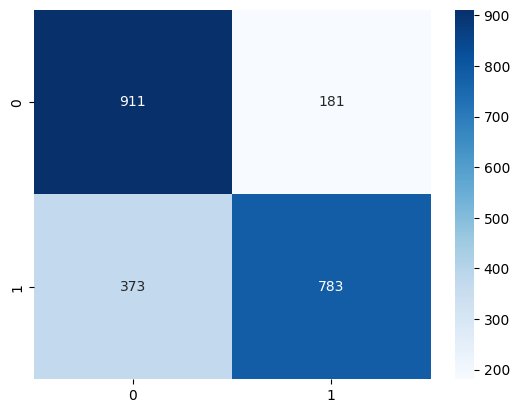

In [9]:
# Convert to classification
median_profit = df['Profit'].median()
df['Is_Profitable'] = (df['Profit'] > median_profit).astype(int)

X_clf = df[['Sales', 'Quantity', 'Discount']]
y_clf = df['Is_Profitable']
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)

log_reg = LogisticRegression()
log_reg.fit(X_train_c, y_train_c)
y_pred_clf = log_reg.predict(X_test_c)

print(f"Classification Accuracy: {accuracy_score(y_test_c, y_pred_clf):.4f}")
print("Confusion Matrix:")
sns.heatmap(confusion_matrix(y_test_c, y_pred_clf), annot=True, fmt='d', cmap='Blues')
plt.show()

## Task 9: Overfitting and Underfitting Analysis

In [10]:
train_error = mean_squared_error(y_train, mlr.predict(X_train))
test_error = mean_squared_error(y_test, y_pred_mlr)
print(f"Training MSE: {train_error:.2f}")
print(f"Testing MSE: {test_error:.2f}")

if train_error < test_error * 0.8:
    print("Potential Overfitting detected.")
elif train_error > test_error * 1.2:
    print("Potential Underfitting detected.")
else:
    print("Model seems well-fitted.")

Training MSE: 27266218.06
Testing MSE: 27219807.49
Model seems well-fitted.


## Task 2 & 13: Data Visualizations

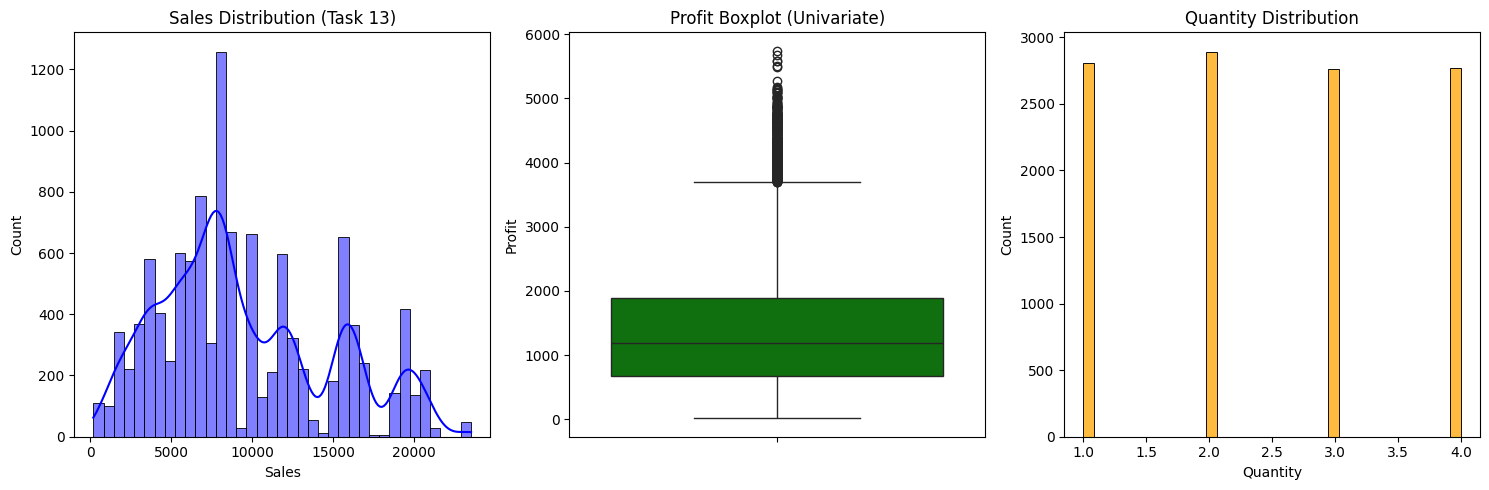

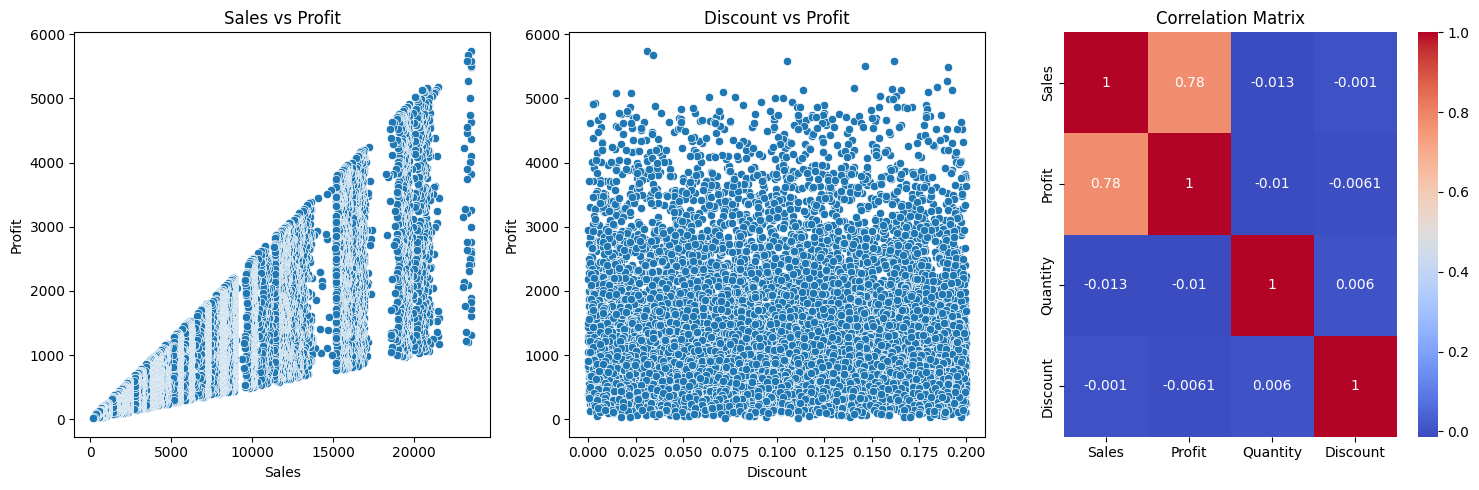

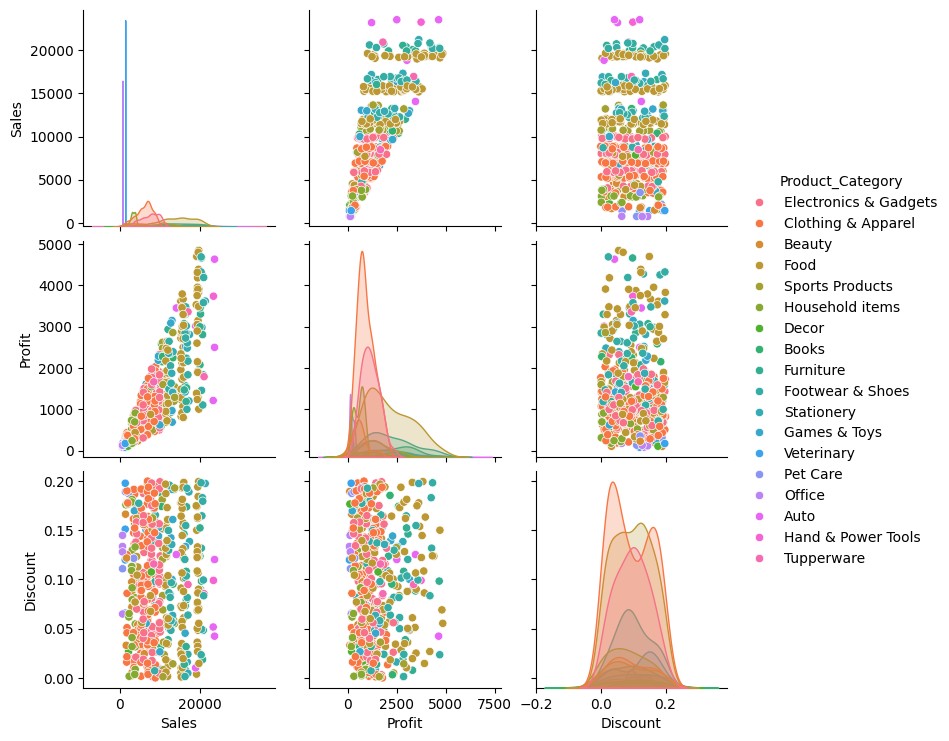

In [11]:
# 1. Univariate Analysis
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.histplot(df['Sales'], kde=True, color='blue')
plt.title('Sales Distribution (Task 13)')

plt.subplot(1, 3, 2)
sns.boxplot(y=df['Profit'], color='green')
plt.title('Profit Boxplot (Univariate)')

plt.subplot(1, 3, 3)
sns.histplot(df['Quantity'], kde=False, color='orange')
plt.title('Quantity Distribution')
plt.tight_layout()
plt.show()

# 2. Bivariate Analysis
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.scatterplot(x='Sales', y='Profit', data=df)
plt.title('Sales vs Profit')

plt.subplot(1, 3, 2)
sns.scatterplot(x='Discount', y='Profit', data=df)
plt.title('Discount vs Profit')

plt.subplot(1, 3, 3)
sns.heatmap(df[['Sales', 'Profit', 'Quantity', 'Discount']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

# 3. Multivariate Analysis
sns.pairplot(df[['Sales', 'Profit', 'Discount', 'Product_Category']].sample(500), hue='Product_Category')
plt.show()

## Final Interpretations
- **Spread**: Calculated skewness and kurtosis show the deviation from normal distribution.
- **ML Models**: Compared regression vs classification approach for sales data.
- **Impact**: Removing outliers helped in achieving a more generalized regression model.